# Análisis de importancia de variables

Este notebook documenta el análisis de importancia relativa de las variables predictoras utilizadas en los modelos de calidad de agua.

El análisis se aplica a los modelos compatibles con el atributo `feature_importances_`, particularmente:

- Gradient Boosting Regressor (GBR),
- Random Forest Regressor (RFR).

El modelo Support Vector Regression (SVR) no se incluye en este análisis directo porque no genera importancias de variables mediante `feature_importances_`. Su interpretación requeriría enfoques alternativos, como importancia por permutación.

## Objetivo

Analizar la contribución relativa de las variables predictoras dentro de los modelos basados en árboles.

El flujo incluye:

1. carga del split y metadatos del entrenamiento,
2. carga de los modelos entrenados,
3. extracción de importancia de variables para modelos compatibles,
4. generación de tablas individuales,
5. generación de tabla consolidada,
6. generación de gráficas de importancia,
7. almacenamiento de productos tabulares y gráficos.

In [1]:
from pathlib import Path
import sys

In [2]:
BASE_DIR = Path.cwd()

while not (BASE_DIR / "src").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR))

print("BASE_DIR detectado:")
print(BASE_DIR)

BASE_DIR detectado:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales


## Importación de funciones auxiliares

Se importan funciones desde los módulos ubicados en `src/calidad_agua/`.

En este notebook se utilizan:

- `cargar_split()` para recuperar los metadatos del entrenamiento,
- `cargar_modelos()` para cargar los modelos entrenados,
- `pipeline_importancia_variables()` para generar tablas y gráficas de importancia.

In [3]:
from src.calidad_agua.preparacion import cargar_split
from src.calidad_agua.inferencia import cargar_modelos
from src.calidad_agua.interpretacion import pipeline_importancia_variables

## Definición de rutas

Se definen las rutas necesarias para cargar los modelos y guardar los productos del análisis de importancia de variables.

Las salidas se organizan por parámetro de calidad de agua, lo que permite mantener separados los resultados de cada variable objetivo modelada.

In [4]:
# ============================================================
# PARÁMETRO DE SALIDA
# ============================================================

# Debe coincidir con el nombre limpio usado en el notebook 02.
# Ejemplo: si target_modelo = "ln_DQO", entonces parametro_salida = "DQO".
parametro_salida = "DQO"

ruta_split = BASE_DIR / "data" / "interim" / "calidad_agua" / "splits" / f"split_{parametro_salida}.joblib"

print("Ruta del split:")
print(ruta_split)

Ruta del split:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\data\interim\calidad_agua\splits\split_DQO.joblib


## Carga del split y metadatos

Se carga el archivo `.joblib` generado durante la preparación del dataset.

Este archivo permite recuperar la variable objetivo (`target`), las variables predictoras (`vars_pred`) y la configuración de transformación utilizada durante el modelado.

In [5]:
split_data = cargar_split(ruta_split)

target_modelo = split_data["target_modelo"]
target_salida = split_data["target_salida"]
vars_pred = split_data["vars_pred"]

crear_ln = split_data["crear_ln"]
aplicar_log = split_data["aplicar_log"]
param_cols_log = split_data["param_cols_log"]
valor_reemplazo_log = split_data["valor_reemplazo_log"]
n_registros = split_data["n_registros"]

print("Variable objetivo usada para modelado:")
print(target_modelo)

print("\nNombre limpio para salidas:")
print(target_salida)

print("\n¿Se crearon columnas logarítmicas?")
print(crear_ln)

print("\n¿El target usa transformación logarítmica?")
print(aplicar_log)

print("\nColumnas base transformadas:")
print(param_cols_log)

print("\nNúmero de registros usado:")
print(n_registros)

print("\nNúmero de variables predictoras:")
print(len(vars_pred))

print("\nVariables predictoras:")
print(vars_pred)

Variable objetivo usada para modelado:
ln_DQO

Nombre limpio para salidas:
DQO

¿Se crearon columnas logarítmicas?
True

¿El target usa transformación logarítmica?
True

Columnas base transformadas:
['DQO', 'Fosfatos', 'Turbidez', 'Nitratos', 'Sulfatos', 'ficocianin', 'Chl', 'CE']

Número de registros usado:
65

Número de variables predictoras:
17

Variables predictoras:
['Blue', 'Green', 'Pan', 'Red', 'RedEdge', 'NIR', 'NDVI', 'NDWI', 'EVI', 'SAVI', 'GNDVI', 'VARI', 'NDRE', 'CIgreen', 'CIRE', 'ARI', 'RENDVI']


## Definición de rutas de modelos y salidas

A partir de `target_salida` se definen las rutas de los modelos entrenados y las carpetas donde se guardarán las tablas y figuras de importancia de variables.

Esto permite que el análisis se organice bajo el nombre limpio del parámetro, aunque el modelo haya sido entrenado con una variable transformada como `ln_DQO`.

In [6]:
carpeta_modelos = BASE_DIR / "models" / "calidad_agua" / "entrenados" / target_salida

rutas_modelos = {
    "SVR": carpeta_modelos / "SVR.joblib",
    "GBR": carpeta_modelos / "GBR.joblib",
    "RFR": carpeta_modelos / "RFR.joblib"
}

carpeta_tablas = BASE_DIR / "outputs" / "tables" / "calidad_agua" / target_salida
carpeta_figuras = BASE_DIR / "outputs" / "figures" / "calidad_agua" / target_salida

print("Rutas de modelos:")
for nombre_modelo, ruta_modelo in rutas_modelos.items():
    print(f"{nombre_modelo}: {ruta_modelo}")

print("\nCarpeta de tablas:")
print(carpeta_tablas)

print("\nCarpeta de figuras:")
print(carpeta_figuras)

Rutas de modelos:
SVR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\models\calidad_agua\entrenados\DQO\SVR.joblib
GBR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\models\calidad_agua\entrenados\DQO\GBR.joblib
RFR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\models\calidad_agua\entrenados\DQO\RFR.joblib

Carpeta de tablas:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\tables\calidad_agua\DQO

Carpeta de figuras:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO


## Carga de modelos entrenados

Se cargan los modelos entrenados para el parámetro de calidad de agua seleccionado.

Aunque se carga el conjunto completo de modelos, el análisis de importancia directa sólo se aplicará a aquellos que sean compatibles con `feature_importances_`.

In [7]:
modelos = cargar_modelos(rutas_modelos)

print("Modelos cargados correctamente:")

for nombre_modelo in modelos.keys():
    print(nombre_modelo)

Modelos cargados correctamente:
SVR
GBR
RFR


## Ejecución del análisis de importancia de variables

Se ejecuta el pipeline de interpretación del modelo.

Este procedimiento:

- identifica qué modelos cuentan con importancia directa de variables,
- omite automáticamente modelos no compatibles, como SVR,
- construye tablas de importancia,
- genera gráficas por modelo,
- y produce una tabla consolidada con los resultados disponibles.

⚠️ Modelo SVR omitido: no contiene feature_importances_. Esto es esperado en modelos como SVR.
Tabla de importancia guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\tables\calidad_agua\DQO\importancia_variables_GBR.csv
Tabla de importancia guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\tables\calidad_agua\DQO\importancia_variables_RFR.csv
Figura de importancia guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\importancia_variables_GBR.png


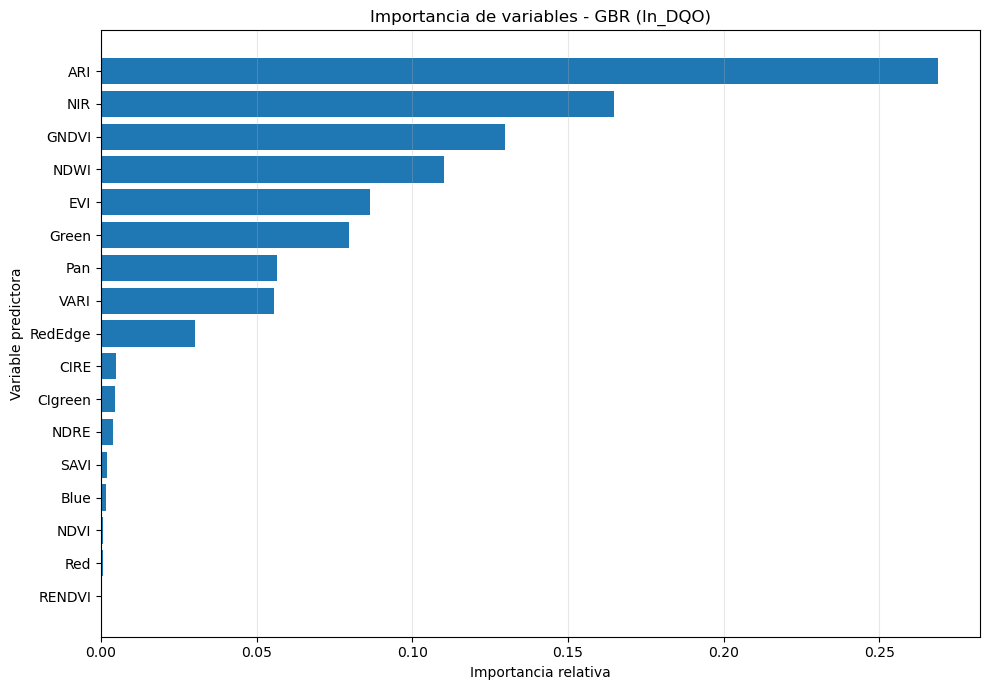

Figura de importancia guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\importancia_variables_RFR.png


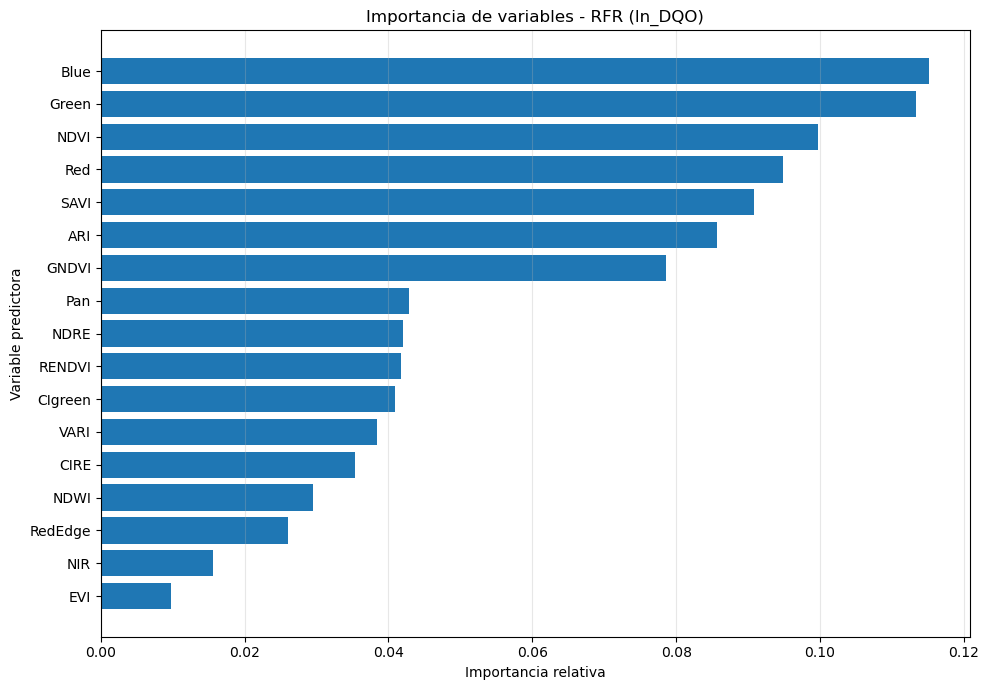

Tabla consolidada de importancia guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\tables\calidad_agua\DQO\importancia_variables_consolidado.csv


In [8]:
resultados_importancia, rutas_tablas, rutas_figuras, df_consolidado = pipeline_importancia_variables(
    modelos=modelos,
    vars_pred=vars_pred,
    target=target_modelo,
    carpeta_tablas=carpeta_tablas,
    carpeta_figuras=carpeta_figuras,
    top_n=None,
    guardar_consolidado=True
)

## Tablas de importancia generadas

Se revisan las rutas de las tablas individuales de importancia de variables generadas para los modelos compatibles.

In [9]:
print("Tablas generadas:")

for nombre_modelo, ruta_tabla in rutas_tablas.items():
    print(f"{nombre_modelo}: {ruta_tabla}")

Tablas generadas:
GBR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\tables\calidad_agua\DQO\importancia_variables_GBR.csv
RFR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\tables\calidad_agua\DQO\importancia_variables_RFR.csv


## Figuras de importancia generadas

Se revisan las rutas de las figuras generadas para visualizar la importancia relativa de las variables predictoras.

In [10]:
print("Figuras generadas:")

for nombre_modelo, ruta_figura in rutas_figuras.items():
    print(f"{nombre_modelo}: {ruta_figura}")

Figuras generadas:
GBR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\importancia_variables_GBR.png
RFR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\importancia_variables_RFR.png


## Tabla consolidada de importancia

La siguiente tabla reúne las importancias de variables para todos los modelos compatibles con este análisis.

Esta tabla facilita la comparación entre modelos basados en árboles, aunque debe recordarse que la magnitud de la importancia no siempre es directamente comparable entre algoritmos diferentes.

In [11]:
df_consolidado

,modelo,variable,importancia
0,GBR,ARI,0.268831
1,GBR,NIR,0.164820
2,GBR,GNDVI,0.129677
3,GBR,NDWI,0.110123
4,GBR,EVI,0.086286
5,GBR,Green,0.079629
6,GBR,Pan,0.056435
7,GBR,VARI,0.055517
8,GBR,RedEdge,0.030124
9,GBR,CIRE,0.004996


## Variables más importantes por modelo

Se presentan las variables con mayor importancia relativa para cada modelo compatible.

In [12]:
for nombre_modelo, df_importancia in resultados_importancia.items():
    print("\n==============================")
    print(f"Modelo: {nombre_modelo}")
    print("==============================")
    display(df_importancia.head(10))


Modelo: GBR


,modelo,variable,importancia
0,GBR,ARI,0.268831
1,GBR,NIR,0.164820
2,GBR,GNDVI,0.129677
3,GBR,NDWI,0.110123
4,GBR,EVI,0.086286
5,GBR,Green,0.079629
6,GBR,Pan,0.056435
7,GBR,VARI,0.055517
8,GBR,RedEdge,0.030124
9,GBR,CIRE,0.004996



Modelo: RFR


,modelo,variable,importancia
0,RFR,Blue,0.115105
1,RFR,Green,0.113355
2,RFR,NDVI,0.099662
3,RFR,Red,0.094823
4,RFR,SAVI,0.090860
5,RFR,ARI,0.085655
6,RFR,GNDVI,0.078557
7,RFR,Pan,0.042809
8,RFR,NDRE,0.042035
9,RFR,RENDVI,0.041782


## Consideraciones técnicas

La importancia de variables basada en `feature_importances_` debe interpretarse como una medida interna del modelo, no como evidencia causal directa.

Algunas consideraciones importantes:

- La importancia puede verse afectada por correlación entre variables predictoras.
- Diferentes modelos pueden asignar importancia de manera distinta.
- En modelos basados en árboles, la importancia suele reflejar la contribución de una variable a la reducción de error o impureza dentro del ensamble.
- SVR no se incluye en este análisis porque no expone importancias directas mediante `feature_importances_`.
- Si se requiere interpretar SVR, se recomienda usar métodos alternativos como importancia por permutación.

## Productos generados

Al finalizar este notebook se generan productos tabulares y gráficos asociados a la interpretación de los modelos.

Para un parámetro como `DQO`, entrenado eventualmente sobre una variable transformada como `ln_DQO`, las salidas se organizan bajo el nombre limpio del parámetro:

Tablas:

- `outputs/tables/calidad_agua/DQO/importancia_variables_GBR.csv`
- `outputs/tables/calidad_agua/DQO/importancia_variables_RFR.csv`
- `outputs/tables/calidad_agua/DQO/importancia_variables_consolidado.csv`

Figuras:

- `outputs/figures/calidad_agua/DQO/importancia_variables_GBR.png`
- `outputs/figures/calidad_agua/DQO/importancia_variables_RFR.png`

## Siguiente etapa del flujo

Una vez evaluados e interpretados los modelos, el siguiente paso consiste en aplicar los modelos entrenados sobre el ortomosaico multibanda del humedal.

Esta fase genera superficies espaciales continuas del parámetro de calidad de agua estimado para cada modelo.

El proceso se documenta en:

`06_prediccion_espacial_modelos.ipynb`